<div style="border-left:6px solid #2a78d6;padding:14px 20px;background:#f4f8fd;border-radius:6px">
<p style="margin:0;color:#52514e;font-size:13px">Data Analytics Básico · Módulo 10 — Presentación de datos</p>
<h1 style="margin:6px 0 0 0;color:#0b0b0b">10. Herramientas de Business Intelligence</h1>
<p style="margin:8px 0 0 0;color:#52514e">Power BI y Tableau: convertir datos en <strong>dashboards interactivos</strong> que el negocio consume solo, sin escribir código. Aquí ves sus conceptos y cómo se conectan con lo que ya sabes.</p>
</div>

> ### Antes de empezar
>
> Ya sabes analizar y graficar en Python. Las **herramientas de BI** (Power BI, Tableau) cubren otra necesidad: dashboards **interactivos, actualizables y de autoservicio** que un gerente explora por su cuenta —filtrando, haciendo *drill-down*— sin depender de un analista para cada pregunta.
>
> No sustituyen a Python; lo complementan. Y muchos conceptos ya los conoces: **Power Query** es limpieza tipo Pandas, una **medida DAX** es una agregación tipo `groupby`, un **modelo estrella** es un `merge` de tablas de hechos y dimensiones. Como Power BI y Tableau son apps externas, aquí simulamos sus ideas con Python y preparamos los datos para consumirlos.

Preparamos el entorno:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Librerías cargadas correctamente")
print(f"Pandas versión: {pd.__version__}")
print(f"NumPy versión: {np.__version__}")

✓ Librerías cargadas correctamente
Pandas versión: 3.0.0
NumPy versión: 2.4.2


## 1. Introducción a Business Intelligence

### ¿Qué es?
**Business Intelligence (BI)** es el conjunto de herramientas y procesos para transformar datos en **decisiones**: integra datos, análisis y visualización en un solo flujo.

### ¿Para qué sirve?
- **Monitorear KPIs** del negocio en tiempo casi real.
- **Detectar desviaciones** y priorizar acciones con evidencia.
- **Democratizar los datos**: que cada área consulte sin depender de TI.

### ¿Cómo se usa?
Preparar datos confiables → modelar las relaciones entre tablas → construir dashboards orientados a preguntas concretas de negocio.

In [2]:
print("=" * 70)
print("¿QUÉ ES BUSINESS INTELLIGENCE?".center(70))
print("=" * 70)

print("""
📊 BUSINESS INTELLIGENCE (BI)

Definición:
  Proceso de recopilación, integración, análisis y presentación de
  información empresarial para apoyar la toma de decisiones.

Componentes principales:
  1. Data Warehousing: Almacenamiento de datos históricos
  2. ETL: Extracción, Transformación y Carga de datos
  3. Análisis de datos: Exploración y descubrimiento de patrones
  4. Visualización: Dashboards e informes interactivos
  5. Reporting: Generación de reportes automáticos

Herramientas populares:
  • Power BI (Microsoft) - Integración con Office, DAX
  • Tableau - Visualización poderosa, fácil de usar
  • Qlik Sense - Análisis asociativo
  • Looker (Google) - SQL-based, embebible
  • Metabase - Open source, simple
  • Apache Superset - Open source, Python

Ventajas:
  ✓ Toma de decisiones basada en datos
  ✓ Identificación de tendencias y patrones
  ✓ Mejora de la eficiencia operativa
  ✓ Ventaja competitiva
  ✓ Dashboards interactivos en tiempo real
""")

# Crear datos de ejemplo para demostración
np.random.seed(42)
fechas = pd.date_range('2023-01-01', '2023-12-31', freq='D')

df_ventas = pd.DataFrame({
    'Fecha': np.repeat(fechas, 3),
    'Producto': np.tile(['Laptop', 'Mouse', 'Teclado'], len(fechas)),
    'Categoria': np.tile(['Computadoras', 'Accesorios', 'Accesorios'], len(fechas)),
    'Region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], len(fechas) * 3),
    'Vendedor': np.random.choice(['Ana', 'Carlos', 'María', 'Luis', 'Pedro'], len(fechas) * 3),
    'Unidades': np.random.randint(1, 20, len(fechas) * 3),
    'Precio_Unitario': np.tile([899.99, 29.99, 79.99], len(fechas)),
})

df_ventas['Ingresos'] = (df_ventas['Unidades'] * df_ventas['Precio_Unitario']).round(2)
df_ventas['Costo'] = (df_ventas['Ingresos'] * np.random.uniform(0.4, 0.6, len(df_ventas))).round(2)
df_ventas['Utilidad'] = (df_ventas['Ingresos'] - df_ventas['Costo']).round(2)
df_ventas['Mes'] = df_ventas['Fecha'].dt.month
df_ventas['Trimestre'] = df_ventas['Fecha'].dt.quarter
df_ventas['Año'] = df_ventas['Fecha'].dt.year

print(f"\n✓ Dataset de ejemplo creado: {df_ventas.shape}")
print(f"  • Período: {df_ventas['Fecha'].min().date()} a {df_ventas['Fecha'].max().date()}")
print(f"  • Total registros: {len(df_ventas):,}")
print(f"  • Productos: {df_ventas['Producto'].nunique()}")
print(f"  • Regiones: {df_ventas['Region'].nunique()}")
print(f"  • Vendedores: {df_ventas['Vendedor'].nunique()}")
print(f"\n{df_ventas.head()}")

                    ¿QUÉ ES BUSINESS INTELLIGENCE?                    

📊 BUSINESS INTELLIGENCE (BI)

Definición:
  Proceso de recopilación, integración, análisis y presentación de
  información empresarial para apoyar la toma de decisiones.

Componentes principales:
  1. Data Warehousing: Almacenamiento de datos históricos
  2. ETL: Extracción, Transformación y Carga de datos
  3. Análisis de datos: Exploración y descubrimiento de patrones
  4. Visualización: Dashboards e informes interactivos
  5. Reporting: Generación de reportes automáticos

Herramientas populares:
  • Power BI (Microsoft) - Integración con Office, DAX
  • Tableau - Visualización poderosa, fácil de usar
  • Qlik Sense - Análisis asociativo
  • Looker (Google) - SQL-based, embebible
  • Metabase - Open source, simple
  • Apache Superset - Open source, Python

Ventajas:
  ✓ Toma de decisiones basada en datos
  ✓ Identificación de tendencias y patrones
  ✓ Mejora de la eficiencia operativa
  ✓ Ventaja competitiva
  ✓ 

> **BI y Python no compiten: se reparten el trabajo.** Las herramientas de BI brillan en **dashboards interactivos y de autoservicio** para usuarios de negocio, que se actualizan solos. Python brilla en **análisis a medida, reproducibilidad y machine learning**. Un flujo típico: Python/SQL preparan y modelan los datos → una herramienta de BI los expone al negocio. Saber ambos te hace mucho más completo.

## 2. Power BI: Conceptos Fundamentales

### ¿Qué es?
La plataforma de BI de Microsoft, la más usada en empresas. Combina un motor de transformación (**Power Query**), un lenguaje de fórmulas (**DAX**) y visualizaciones interactivas.

### El modelo estrella (*star schema*)

Es la forma estándar de organizar los datos en BI: una **tabla de hechos** en el centro (los eventos medibles) rodeada de **tablas de dimensión** (el contexto).

| Tipo de tabla | Contiene | Ejemplo |
|---|---|---|
| **Hechos** (*fact*) | Los números a medir, con claves | Ventas: fecha, id_producto, id_cliente, monto |
| **Dimensión** (*dim*) | El contexto descriptivo | Productos, Clientes, Calendario |

En esencia, es el `merge` de Pandas visto como diseño: las dimensiones se "unen" a los hechos por sus claves.

### ¿Cómo se usa?
Cargas las tablas de hechos y dimensiones, defines las relaciones (claves) del modelo, y creas visuales y medidas para el seguimiento ejecutivo.

In [3]:
print("=" * 70)
print("POWER BI: CONCEPTOS FUNDAMENTALES".center(70))
print("=" * 70)

print("""
🔷 MICROSOFT POWER BI

Componentes:
  1. Power BI Desktop: Aplicación de escritorio para crear informes
  2. Power BI Service: Servicio en la nube para compartir dashboards
  3. Power BI Mobile: Apps móviles para iOS y Android
  4. Power BI Embedded: Para desarrolladores (embeber en apps)

Proceso de trabajo:
  1. CONECTAR → Obtener datos de múltiples fuentes
  2. TRANSFORMAR → Limpiar y modelar datos (Power Query)
  3. MODELAR → Crear relaciones entre tablas
  4. VISUALIZAR → Crear gráficos y dashboards
  5. ANALIZAR → Usar DAX para cálculos avanzados
  6. COMPARTIR → Publicar en Power BI Service

Fuentes de datos soportadas:
  • Excel, CSV, TXT
  • SQL Server, MySQL, PostgreSQL, Oracle
  • Azure, Dynamics 365, SharePoint
  • Google Analytics, Salesforce
  • APIs REST, OData
  • Python, R scripts
  • +100 conectores nativos

Tipos de visualizaciones:
  📊 Gráficos de barras/columnas
  📈 Gráficos de líneas/áreas
  🥧 Gráficos circulares/donas
  🗺️ Mapas geográficos
  📉 Dispersión y burbujas
  📋 Tablas y matrices
  🎯 KPIs y tarjetas
  🔢 Slicers (filtros visuales)
  📊 Gráficos personalizados (marketplace)
""")

print("\n" + "=" * 70)
print("PREPARACIÓN DE DATOS PARA POWER BI".center(70))
print("=" * 70)

# Exportar datos preparados para Power BI
print("\n1. EXPORTAR A CSV (formato compatible)")
print("-" * 70)

df_ventas.to_csv('ventas_para_powerbi.csv', index=False, encoding='utf-8-sig')
print("✓ Archivo CSV creado: ventas_para_powerbi.csv")
print("  Encoding: UTF-8 con BOM (compatible con Excel/Power BI)")

# Crear tabla de calendario (muy importante en Power BI)
print("\n2. CREAR TABLA DE CALENDARIO (Date Table)")
print("-" * 70)
print("En Power BI es esencial tener una tabla de calendario con DAX:")
print("""
Calendario = 
ADDCOLUMNS(
    CALENDAR(DATE(2023,1,1), DATE(2023,12,31)),
    "Año", YEAR([Date]),
    "Mes", MONTH([Date]),
    "Nombre Mes", FORMAT([Date], "MMMM"),
    "Trimestre", "Q" & FORMAT([Date], "Q"),
    "Día Semana", WEEKDAY([Date]),
    "Nombre Día", FORMAT([Date], "dddd")
)
""")

# Crear tabla de calendario en Python
fechas_rango = pd.date_range('2023-01-01', '2023-12-31', freq='D')
df_calendario = pd.DataFrame({
    'Fecha': fechas_rango,
    'Año': fechas_rango.year,
    'Mes': fechas_rango.month,
    'Nombre_Mes': fechas_rango.strftime('%B'),
    'Trimestre': 'Q' + fechas_rango.quarter.astype(str),
    'Dia_Semana': fechas_rango.dayofweek + 1,
    'Nombre_Dia': fechas_rango.strftime('%A'),
    'Semana_Año': fechas_rango.isocalendar().week,
    'Es_Fin_Semana': fechas_rango.dayofweek.isin([5, 6]).astype(int)
})

df_calendario.to_csv('calendario_para_powerbi.csv', index=False, encoding='utf-8-sig')
print("✓ Tabla de calendario creada en Python:")
print(df_calendario.head())

print("\n3. ESTRUCTURA DE DATOS PARA MODELO ESTRELLA (Star Schema)")
print("-" * 70)
print("""
Modelo recomendado en Power BI:

  TABLAS DE HECHOS (Fact Tables):
    • Ventas (transacciones)
    • Contiene claves foráneas y métricas
  
  TABLAS DE DIMENSIONES (Dimension Tables):
    • Calendario (tiempo)
    • Productos (qué)
    • Clientes (quién)
    • Regiones (dónde)
    • Vendedores (quién vende)
""")

# Crear tablas dimensionales
dim_productos = df_ventas[['Producto', 'Categoria', 'Precio_Unitario']].drop_duplicates().reset_index(drop=True)
dim_productos['ID_Producto'] = range(1, len(dim_productos) + 1)

dim_regiones = pd.DataFrame({
    'ID_Region': range(1, 5),
    'Region': ['Norte', 'Sur', 'Este', 'Oeste'],
    'Pais': ['México'] * 4
})

dim_vendedores = pd.DataFrame({
    'ID_Vendedor': range(1, 6),
    'Vendedor': ['Ana', 'Carlos', 'María', 'Luis', 'Pedro'],
    'Antiguedad_Años': [5, 3, 7, 2, 4]
})

print("\n✓ Tablas dimensionales creadas:")
print(f"  • Productos: {len(dim_productos)} registros")
print(f"  • Regiones: {len(dim_regiones)} registros")
print(f"  • Vendedores: {len(dim_vendedores)} registros")

# Exportar dimensiones
dim_productos.to_csv('dim_productos.csv', index=False, encoding='utf-8-sig')
dim_regiones.to_csv('dim_regiones.csv', index=False, encoding='utf-8-sig')
dim_vendedores.to_csv('dim_vendedores.csv', index=False, encoding='utf-8-sig')

print("\n✓ Archivos exportados para modelo estrella en Power BI:")
print("  • ventas_para_powerbi.csv (Fact table)")
print("  • calendario_para_powerbi.csv (Dim tiempo)")
print("  • dim_productos.csv")
print("  • dim_regiones.csv")
print("  • dim_vendedores.csv")

                  POWER BI: CONCEPTOS FUNDAMENTALES                   

🔷 MICROSOFT POWER BI

Componentes:
  1. Power BI Desktop: Aplicación de escritorio para crear informes
  2. Power BI Service: Servicio en la nube para compartir dashboards
  3. Power BI Mobile: Apps móviles para iOS y Android
  4. Power BI Embedded: Para desarrolladores (embeber en apps)

Proceso de trabajo:
  1. CONECTAR → Obtener datos de múltiples fuentes
  2. TRANSFORMAR → Limpiar y modelar datos (Power Query)
  3. MODELAR → Crear relaciones entre tablas
  4. VISUALIZAR → Crear gráficos y dashboards
  5. ANALIZAR → Usar DAX para cálculos avanzados
  6. COMPARTIR → Publicar en Power BI Service

Fuentes de datos soportadas:
  • Excel, CSV, TXT
  • SQL Server, MySQL, PostgreSQL, Oracle
  • Azure, Dynamics 365, SharePoint
  • Google Analytics, Salesforce
  • APIs REST, OData
  • Python, R scripts
  • +100 conectores nativos

Tipos de visualizaciones:
  📊 Gráficos de barras/columnas
  📈 Gráficos de líneas/áreas
  🥧 

## 3. Power Query: Transformación de Datos

### ¿Qué es?
El motor **ETL** de Power BI: extrae, limpia y transforma los datos **antes** del modelado. Es la limpieza que ya hiciste con Pandas, pero con interfaz visual y pasos grabados.

### ¿Para qué sirve?
Asegurar la calidad de los datos y estandarizar transformaciones **repetibles**: cuando llegan datos nuevos, se re-aplican solas.

### ¿Cómo se usa?
Limpiar nulos y formatos → crear columnas derivadas → combinar tablas, dejando el dataset listo para el modelo.

In [4]:
print("=" * 70)
print("POWER QUERY: TRANSFORMACIONES".center(70))
print("=" * 70)

print("""
🔄 POWER QUERY EDITOR

Es el motor de ETL integrado en Power BI para:
  • Conectar a fuentes de datos
  • Limpiar y transformar datos
  • Combinar múltiples tablas
  • Crear columnas calculadas
  • Todo sin escribir código (interfaz visual)
  • Genera código M (lenguaje de Power Query)

Transformaciones comunes:
  1. Quitar columnas/filas
  2. Filtrar datos
  3. Cambiar tipos de datos
  4. Dividir columnas
  5. Combinar/Agregar consultas (merge/append)
  6. Agrupar por
  7. Anular dinamización (unpivot)
  8. Columnas condicionales
  9. Reemplazar valores
  10. Quitar duplicados
""")

print("\n" + "=" * 70)
print("EJEMPLOS DE TRANSFORMACIONES (Python equivalente)".center(70))
print("=" * 70)

# Ejemplo 1: Limpiar datos
print("\n1. LIMPIEZA DE DATOS")
print("-" * 70)

# Crear datos sucios
df_sucio = df_ventas.copy()
df_sucio.loc[0:10, 'Unidades'] = np.nan  # Valores nulos
df_sucio['Region'] = df_sucio['Region'].str.upper()  # Inconsistencia

print("Antes de limpiar:")
print(f"  • Valores nulos: {df_sucio.isnull().sum().sum()}")
print(f"  • Regiones únicas: {df_sucio['Region'].unique()}")

# Power Query: Quitar filas con nulos → Cambiar a mayúsculas
df_limpio = df_sucio.dropna()
df_limpio['Region'] = df_limpio['Region'].str.title()

print("\nDespués de limpiar:")
print(f"  • Valores nulos: {df_limpio.isnull().sum().sum()}")
print(f"  • Regiones únicas: {df_limpio['Region'].unique()}")

# Ejemplo 2: Agrupar datos
print("\n2. AGRUPAR DATOS (Group By)")
print("-" * 70)
print("Power Query: Group By → Sum, Average, Count, etc.")

agrupado = df_ventas.groupby(['Producto', 'Region']).agg({
    'Ingresos': 'sum',
    'Unidades': 'sum',
    'Fecha': 'count'
}).round(2)
agrupado.columns = ['Total_Ingresos', 'Total_Unidades', 'Num_Transacciones']

print(agrupado.head(10))

# Ejemplo 3: Columnas condicionales
print("\n3. COLUMNAS CONDICIONALES")
print("-" * 70)
print("Power Query: Add Column → Conditional Column")

df_ventas['Segmento_Ingreso'] = pd.cut(
    df_ventas['Ingresos'],
    bins=[0, 500, 2000, float('inf')],
    labels=['Bajo', 'Medio', 'Alto']
)

print(df_ventas[['Producto', 'Ingresos', 'Segmento_Ingreso']].head(10))

# Ejemplo 4: Combinar consultas
print("\n4. COMBINAR CONSULTAS (Merge)")
print("-" * 70)
print("Power Query: Merge Queries (Left, Right, Inner, Outer)")

# Crear tabla de metas
df_metas = pd.DataFrame({
    'Producto': ['Laptop', 'Mouse', 'Teclado'],
    'Meta_Anual': [500000, 150000, 200000]
})

# Combinar con ventas
ventas_con_meta = df_ventas.groupby('Producto')['Ingresos'].sum().reset_index()
ventas_con_meta = ventas_con_meta.merge(df_metas, on='Producto', how='left')
ventas_con_meta['% Cumplimiento'] = (
    (ventas_con_meta['Ingresos'] / ventas_con_meta['Meta_Anual']) * 100
).round(2)

print(ventas_con_meta)

print("""
\n💡 EJEMPLO DE CÓDIGO M (Power Query):

let
    Origen = Csv.Document(File.Contents("ventas.csv")),
    EncabezadosPromovidos = Table.PromoteHeaders(Origen),
    TiposCambiados = Table.TransformColumnTypes(EncabezadosPromovidos, {
        {"Fecha", type date},
        {"Ingresos", type number}
    }),
    FilasFiltradas = Table.SelectRows(TiposCambiados, each [Ingresos] > 100),
    ColumnaAgregada = Table.AddColumn(FilasFiltradas, "Año", each Date.Year([Fecha]))
in
    ColumnaAgregada
""")

                    POWER QUERY: TRANSFORMACIONES                     

🔄 POWER QUERY EDITOR

Es el motor de ETL integrado en Power BI para:
  • Conectar a fuentes de datos
  • Limpiar y transformar datos
  • Combinar múltiples tablas
  • Crear columnas calculadas
  • Todo sin escribir código (interfaz visual)
  • Genera código M (lenguaje de Power Query)

Transformaciones comunes:
  1. Quitar columnas/filas
  2. Filtrar datos
  3. Cambiar tipos de datos
  4. Dividir columnas
  5. Combinar/Agregar consultas (merge/append)
  6. Agrupar por
  7. Anular dinamización (unpivot)
  8. Columnas condicionales
  9. Reemplazar valores
  10. Quitar duplicados


          EJEMPLOS DE TRANSFORMACIONES (Python equivalente)           

1. LIMPIEZA DE DATOS
----------------------------------------------------------------------
Antes de limpiar:
  • Valores nulos: 11
  • Regiones únicas: <ArrowStringArray>
['ESTE', 'OESTE', 'NORTE', 'SUR']
Length: 4, dtype: str

Después de limpiar:
  • Valores nulos: 0


## 4. DAX: Data Analysis Expressions

### ¿Qué es?
El lenguaje de fórmulas de Power BI para crear **medidas** y columnas calculadas. Una medida DAX es, conceptualmente, una agregación que se recalcula según los filtros activos del dashboard.

### ¿Para qué sirve?
Construir lógica analítica dinámica: totales, acumulados y comparativos temporales (año vs. año anterior) que responden al contexto que el usuario filtra.

### ¿Cómo se usa?
Empiezas con medidas base (`SUM`, `COUNT`, `AVERAGE`), las extiendes con `CALCULATE` (que cambia el contexto de filtro) y añades inteligencia temporal para comparar periodos.

In [5]:
print("=" * 70)
print("DAX: DATA ANALYSIS EXPRESSIONS".center(70))
print("=" * 70)

print("""
📐 ¿QUÉ ES DAX?

Lenguaje de fórmulas para:
  • Crear medidas (cálculos dinámicos)
  • Crear columnas calculadas
  • Crear tablas calculadas
  • Análisis de inteligencia de tiempo

Tipos de cálculos:
  1. MEDIDAS: Se calculan en tiempo real según contexto
  2. COLUMNAS CALCULADAS: Se calculan al cargar datos
  3. TABLAS CALCULADAS: Nuevas tablas basadas en otras

Categorías de funciones DAX:
  • Agregación: SUM, AVERAGE, COUNT, MIN, MAX
  • Lógicas: IF, AND, OR, NOT, SWITCH
  • Filtro: CALCULATE, FILTER, ALL, ALLSELECTED
  • Iteración: SUMX, AVERAGEX, RANKX
  • Tiempo: DATESYTD, SAMEPERIODLASTYEAR, DATEADD
  • Relaciones: RELATED, RELATEDTABLE
  • Información: ISBLANK, HASONEVALUE
""")

print("\n" + "=" * 70)
print("MEDIDAS DAX Y SUS EQUIVALENTES EN PYTHON".center(70))
print("=" * 70)

# 1. Medidas básicas de agregación
print("\n1. MEDIDAS BÁSICAS")
print("-" * 70)

print("""
DAX: Total Ingresos = SUM(Ventas[Ingresos])
Python: df_ventas['Ingresos'].sum()
""")
total_ingresos = df_ventas['Ingresos'].sum()
print(f"Total Ingresos: ${total_ingresos:,.2f}")

print("""
DAX: Ingresos Promedio = AVERAGE(Ventas[Ingresos])
Python: df_ventas['Ingresos'].mean()
""")
ingresos_promedio = df_ventas['Ingresos'].mean()
print(f"Ingresos Promedio: ${ingresos_promedio:,.2f}")

print("""
DAX: Num Transacciones = COUNTROWS(Ventas)
Python: len(df_ventas)
""")
num_transacciones = len(df_ventas)
print(f"Número de Transacciones: {num_transacciones:,}")

# 2. Medidas con CALCULATE (filtros)
print("\n2. CALCULATE - Modificar contexto de filtro")
print("-" * 70)

print("""
DAX: Ingresos Laptops = CALCULATE(
    SUM(Ventas[Ingresos]),
    Ventas[Producto] = "Laptop"
)
Python: df_ventas[df_ventas['Producto'] == 'Laptop']['Ingresos'].sum()
""")
ingresos_laptops = df_ventas[df_ventas['Producto'] == 'Laptop']['Ingresos'].sum()
print(f"Ingresos Laptops: ${ingresos_laptops:,.2f}")

print("""
DAX: Ingresos Norte = CALCULATE(
    SUM(Ventas[Ingresos]),
    Ventas[Region] = "Norte"
)
""")
ingresos_norte = df_ventas[df_ventas['Region'] == 'Norte']['Ingresos'].sum()
print(f"Ingresos Región Norte: ${ingresos_norte:,.2f}")

# 3. Medidas con ALL (ignorar filtros)
print("\n3. ALL - Ignorar filtros")
print("-" * 70)

print("""
DAX: % del Total = 
DIVIDE(
    SUM(Ventas[Ingresos]),
    CALCULATE(SUM(Ventas[Ingresos]), ALL(Ventas))
)
""")

# Por producto
ingresos_por_producto = df_ventas.groupby('Producto')['Ingresos'].sum()
pct_del_total = (ingresos_por_producto / df_ventas['Ingresos'].sum() * 100).round(2)
print("\nPorcentaje del Total por Producto:")
for prod, pct in pct_del_total.items():
    print(f"  {prod}: {pct}%")

# 4. Funciones de iteración (X)
print("\n4. FUNCIONES DE ITERACIÓN (X)")
print("-" * 70)

print("""
DAX: Total con Descuento = SUMX(
    Ventas,
    Ventas[Unidades] * Ventas[Precio_Unitario] * 0.9
)
Python: (df_ventas['Unidades'] * df_ventas['Precio_Unitario'] * 0.9).sum()
""")
total_con_descuento = (df_ventas['Unidades'] * df_ventas['Precio_Unitario'] * 0.9).sum()
print(f"Total con 10% descuento: ${total_con_descuento:,.2f}")

# 5. Time Intelligence
print("\n5. TIME INTELLIGENCE - Inteligencia de tiempo")
print("-" * 70)

print("""
DAX: Ventas Año Anterior = CALCULATE(
    SUM(Ventas[Ingresos]),
    SAMEPERIODLASTYEAR(Calendario[Fecha])
)
""")

# Simular datos de año anterior
df_2022 = df_ventas.copy()
df_2022['Fecha'] = df_2022['Fecha'] - pd.DateOffset(years=1)
df_2022['Año'] = 2022
df_2022['Ingresos'] = df_2022['Ingresos'] * 0.85  # 85% del año actual

df_dos_años = pd.concat([df_2022, df_ventas], ignore_index=True)

# Comparación año sobre año
print("""
DAX: Crecimiento YoY % = 
DIVIDE(
    [Total Ingresos] - [Ventas Año Anterior],
    [Ventas Año Anterior]
)
""")

ingresos_por_año = df_dos_años.groupby('Año')['Ingresos'].sum()
crecimiento_yoy = (
    (ingresos_por_año[2023] - ingresos_por_año[2022]) / ingresos_por_año[2022] * 100
).round(2)

print(f"\nIngresos 2022: ${ingresos_por_año[2022]:,.2f}")
print(f"Ingresos 2023: ${ingresos_por_año[2023]:,.2f}")
print(f"Crecimiento YoY: {crecimiento_yoy}%")

# 6. Funciones lógicas
print("\n6. FUNCIONES LÓGICAS")
print("-" * 70)

print("""
DAX: Clasificacion Venta = 
SWITCH(
    TRUE(),
    Ventas[Ingresos] > 10000, "Premium",
    Ventas[Ingresos] > 5000, "Alta",
    Ventas[Ingresos] > 1000, "Media",
    "Baja"
)
""")

condiciones = [
    df_ventas['Ingresos'] > 10000,
    df_ventas['Ingresos'] > 5000,
    df_ventas['Ingresos'] > 1000
]
valores = ['Premium', 'Alta', 'Media']
df_ventas['Clasificacion'] = np.select(condiciones, valores, default='Baja')

print("\nDistribución de ventas por clasificación:")
print(df_ventas['Clasificacion'].value_counts())

print("""
\n💡 MEDIDAS DAX MÁS COMUNES:

Ventas:
  Total Ventas = SUM(Ventas[Ingresos])
  Total Unidades = SUM(Ventas[Unidades])
  Ticket Promedio = DIVIDE([Total Ventas], COUNTROWS(Ventas))

Márgenes:
  Margen = SUM(Ventas[Ingresos]) - SUM(Ventas[Costo])
  Margen % = DIVIDE([Margen], [Total Ventas])

Comparaciones temporales:
  Ventas Mes Anterior = CALCULATE([Total Ventas], DATEADD(Calendario[Fecha], -1, MONTH))
  Ventas Acumuladas = CALCULATE([Total Ventas], DATESYTD(Calendario[Fecha]))
  
Ranking:
  Ranking Productos = RANKX(ALL(Productos), [Total Ventas],, DESC, Dense)
""")

                    DAX: DATA ANALYSIS EXPRESSIONS                    

📐 ¿QUÉ ES DAX?

Lenguaje de fórmulas para:
  • Crear medidas (cálculos dinámicos)
  • Crear columnas calculadas
  • Crear tablas calculadas
  • Análisis de inteligencia de tiempo

Tipos de cálculos:
  1. MEDIDAS: Se calculan en tiempo real según contexto
  2. COLUMNAS CALCULADAS: Se calculan al cargar datos
  3. TABLAS CALCULADAS: Nuevas tablas basadas en otras

Categorías de funciones DAX:
  • Agregación: SUM, AVERAGE, COUNT, MIN, MAX
  • Lógicas: IF, AND, OR, NOT, SWITCH
  • Filtro: CALCULATE, FILTER, ALL, ALLSELECTED
  • Iteración: SUMX, AVERAGEX, RANKX
  • Tiempo: DATESYTD, SAMEPERIODLASTYEAR, DATEADD
  • Relaciones: RELATED, RELATEDTABLE
  • Información: ISBLANK, HASONEVALUE


               MEDIDAS DAX Y SUS EQUIVALENTES EN PYTHON               

1. MEDIDAS BÁSICAS
----------------------------------------------------------------------

DAX: Total Ingresos = SUM(Ventas[Ingresos])
Python: df_ventas['Ingresos'].

> **DAX: medida vs. columna calculada (la confusión clásica).** Una **columna calculada** se computa **una vez por fila al cargar** los datos y ocupa memoria. Una **medida** se calcula **al vuelo**, según los filtros que el usuario aplica en el dashboard, y casi no ocupa memoria. Regla práctica: para agregaciones (totales, promedios, ratios) usa **medidas**; reserva las columnas calculadas para valores por fila que necesites filtrar o agrupar.

## 5. Visualizaciones y Dashboards en Power BI

### ¿Qué es?
Un dashboard combina varias visualizaciones **conectadas** (al filtrar una, se actualizan las demás) para el seguimiento integral del negocio.

### ¿Para qué sirve?
Leer de un vistazo el estado actual y detectar oportunidades o riesgos, con interactividad que invita a explorar.

### ¿Cómo se usa?
Define los KPIs principales, organiza los visuales por narrativa (resumen → detalle → acción) y mantén consistencia visual con filtros claros.

                    DISEÑO DE DASHBOARDS EFECTIVOS                    

📊 PRINCIPIOS DE DISEÑO DE DASHBOARDS

1. JERARQUÍA VISUAL
   • KPIs principales arriba
   • Gráficos de tendencia en el centro
   • Detalles abajo
   • Diseño en forma de Z o F

2. REGLA DEL 5 SEGUNDOS
   • El usuario debe entender el mensaje en 5 segundos
   • Título claro y descriptivo
   • No más de 5-7 visualizaciones por página

3. COLOR Y CONTRASTE
   • Usar paleta corporativa
   • Máximo 3-4 colores principales
   • Resaltar lo importante
   • Considerar daltonismo

4. INTERACTIVIDAD
   • Filtros (slicers) visibles y fáciles de usar
   • Cross-filtering entre visualizaciones
   • Drill-down para mayor detalle
   • Tooltips informativos

5. PERFORMANCE
   • Evitar visualizaciones complejas innecesarias
   • Limitar número de visuales por página
   • Usar medidas en lugar de columnas calculadas cuando sea posible
   • Optimizar modelo de datos


                 TIPOS DE VISUALIZACIONES Y SUS USOS             

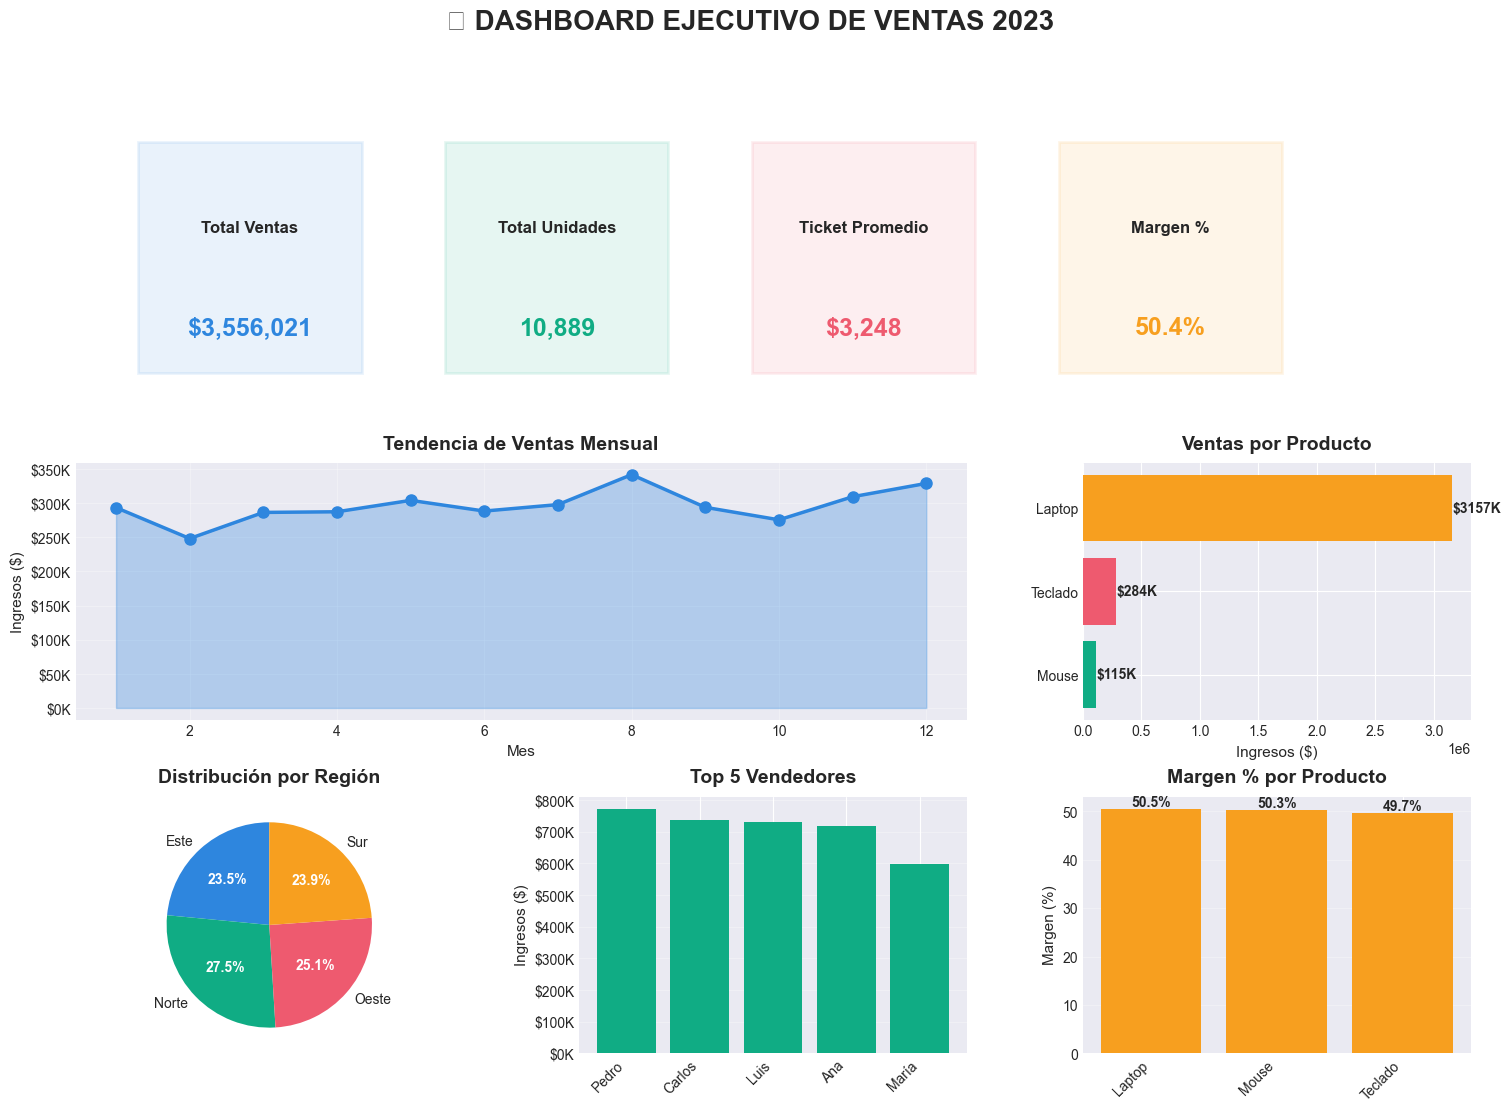


✓ Dashboard de ejemplo creado: dashboard_ejemplo.png

💡 Este tipo de dashboard es lo que se crea en Power BI:
  • KPIs destacados en la parte superior
  • Visualizaciones variadas (líneas, barras, pastel)
  • Diseño limpio y organizado
  • Colores consistentes
  • Información clara y accionable


In [6]:
print("=" * 70)
print("DISEÑO DE DASHBOARDS EFECTIVOS".center(70))
print("=" * 70)

print("""
📊 PRINCIPIOS DE DISEÑO DE DASHBOARDS

1. JERARQUÍA VISUAL
   • KPIs principales arriba
   • Gráficos de tendencia en el centro
   • Detalles abajo
   • Diseño en forma de Z o F

2. REGLA DEL 5 SEGUNDOS
   • El usuario debe entender el mensaje en 5 segundos
   • Título claro y descriptivo
   • No más de 5-7 visualizaciones por página

3. COLOR Y CONTRASTE
   • Usar paleta corporativa
   • Máximo 3-4 colores principales
   • Resaltar lo importante
   • Considerar daltonismo

4. INTERACTIVIDAD
   • Filtros (slicers) visibles y fáciles de usar
   • Cross-filtering entre visualizaciones
   • Drill-down para mayor detalle
   • Tooltips informativos

5. PERFORMANCE
   • Evitar visualizaciones complejas innecesarias
   • Limitar número de visuales por página
   • Usar medidas en lugar de columnas calculadas cuando sea posible
   • Optimizar modelo de datos
""")

print("\n" + "=" * 70)
print("TIPOS DE VISUALIZACIONES Y SUS USOS".center(70))
print("=" * 70)

print("""
📈 CUÁNDO USAR CADA TIPO DE GRÁFICO:

GRÁFICOS DE BARRAS/COLUMNAS:
  ✓ Comparar categorías
  ✓ Top N productos/clientes/regiones
  ✓ Mostrar ranking
  
GRÁFICOS DE LÍNEAS:
  ✓ Tendencias en el tiempo
  ✓ Comparar múltiples series temporales
  ✓ Proyecciones y forecasting

GRÁFICOS CIRCULARES/DONAS:
  ✓ Composición (partes del todo)
  ✓ Máximo 5-6 categorías
  ✓ Distribución porcentual

TARJETAS (KPI):
  ✓ Métricas clave individuales
  ✓ Números de un vistazo
  ✓ Con indicadores vs objetivo/período anterior

MAPAS:
  ✓ Distribución geográfica
  ✓ Identificar patrones espaciales
  ✓ Comparar regiones

TABLAS/MATRICES:
  ✓ Datos detallados
  ✓ Análisis multidimensional
  ✓ Cuando se necesita precisión numérica

GRÁFICOS DE DISPERSIÓN:
  ✓ Correlaciones entre variables
  ✓ Análisis de segmentación
  ✓ Detección de outliers
""")

# Crear ejemplo de dashboard con Python
print("\n" + "=" * 70)
print("EJEMPLO: DASHBOARD DE VENTAS (simulado en Python)".center(70))
print("=" * 70)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Estilo de título
fig.suptitle('📊 DASHBOARD EJECUTIVO DE VENTAS 2023', 
             fontsize=20, fontweight='bold', y=0.98)

# 1. KPIs principales (arriba)
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')

kpis = [
    ('Total Ventas', f"${df_ventas['Ingresos'].sum():,.0f}", '#2E86DE'),
    ('Total Unidades', f"{df_ventas['Unidades'].sum():,}", '#10AC84'),
    ('Ticket Promedio', f"${df_ventas['Ingresos'].mean():,.0f}", '#EE5A6F'),
    ('Margen %', f"{(df_ventas['Utilidad'].sum() / df_ventas['Ingresos'].sum() * 100):.1f}%", '#F79F1F')
]

for i, (label, value, color) in enumerate(kpis):
    x_pos = 0.125 + i * 0.22
    ax_kpi.text(x_pos, 0.6, label, ha='center', fontsize=12, 
                transform=ax_kpi.transAxes, weight='bold')
    ax_kpi.text(x_pos, 0.2, value, ha='center', fontsize=18, 
                transform=ax_kpi.transAxes, weight='bold', color=color)
    # Rectángulo de fondo
    from matplotlib.patches import Rectangle
    rect = Rectangle((x_pos - 0.08, 0.05), 0.16, 0.9, 
                     transform=ax_kpi.transAxes, 
                     facecolor=color, alpha=0.1, edgecolor=color, linewidth=2)
    ax_kpi.add_patch(rect)

# 2. Tendencia mensual (centro-izquierda superior)
ax1 = fig.add_subplot(gs[1, :2])
ventas_mensuales = df_ventas.groupby('Mes')['Ingresos'].sum()
ax1.plot(ventas_mensuales.index, ventas_mensuales.values, 
         marker='o', linewidth=2.5, markersize=8, color='#2E86DE')
ax1.fill_between(ventas_mensuales.index, ventas_mensuales.values, alpha=0.3, color='#2E86DE')
ax1.set_title('Tendencia de Ventas Mensual', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Mes', fontsize=11)
ax1.set_ylabel('Ingresos ($)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# 3. Top productos (derecha superior)
ax2 = fig.add_subplot(gs[1, 2])
top_productos = df_ventas.groupby('Producto')['Ingresos'].sum().sort_values(ascending=True)
colors = ['#10AC84', '#EE5A6F', '#F79F1F']
bars = ax2.barh(top_productos.index, top_productos.values, color=colors)
ax2.set_title('Ventas por Producto', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Ingresos ($)', fontsize=11)
# Agregar valores
for bar in bars:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2, 
             f'${width/1000:.0f}K', ha='left', va='center', fontsize=10, weight='bold')

# 4. Distribución por región (centro-izquierda inferior)
ax3 = fig.add_subplot(gs[2, 0])
ventas_region = df_ventas.groupby('Region')['Ingresos'].sum()
colors_pie = ['#2E86DE', '#10AC84', '#EE5A6F', '#F79F1F']
wedges, texts, autotexts = ax3.pie(ventas_region.values, labels=ventas_region.index, 
                                     autopct='%1.1f%%', startangle=90, 
                                     colors=colors_pie, textprops={'fontsize': 10})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax3.set_title('Distribución por Región', fontsize=14, fontweight='bold', pad=10)

# 5. Top vendedores (centro inferior)
ax4 = fig.add_subplot(gs[2, 1])
top_vendedores = df_ventas.groupby('Vendedor')['Ingresos'].sum().sort_values(ascending=False).head(5)
bars = ax4.bar(range(len(top_vendedores)), top_vendedores.values, color='#10AC84')
ax4.set_xticks(range(len(top_vendedores)))
ax4.set_xticklabels(top_vendedores.index, rotation=45, ha='right')
ax4.set_title('Top 5 Vendedores', fontsize=14, fontweight='bold', pad=10)
ax4.set_ylabel('Ingresos ($)', fontsize=11)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax4.grid(True, axis='y', alpha=0.3)

# 6. Margen por producto (derecha inferior)
ax5 = fig.add_subplot(gs[2, 2])
margen_producto = df_ventas.groupby('Producto').agg({
    'Ingresos': 'sum',
    'Utilidad': 'sum'
})
margen_producto['Margen_%'] = (margen_producto['Utilidad'] / margen_producto['Ingresos'] * 100)
bars = ax5.bar(margen_producto.index, margen_producto['Margen_%'], color='#F79F1F')
ax5.set_title('Margen % por Producto', fontsize=14, fontweight='bold', pad=10)
ax5.set_ylabel('Margen (%)', fontsize=11)
ax5.set_xticklabels(margen_producto.index, rotation=45, ha='right')
ax5.grid(True, axis='y', alpha=0.3)
# Agregar valores
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('dashboard_ejemplo.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Dashboard de ejemplo creado: dashboard_ejemplo.png")
print("\n💡 Este tipo de dashboard es lo que se crea en Power BI:")
print("  • KPIs destacados en la parte superior")
print("  • Visualizaciones variadas (líneas, barras, pastel)")
print("  • Diseño limpio y organizado")
print("  • Colores consistentes")
print("  • Información clara y accionable")

> **La regla de los 5 segundos.** Un buen dashboard comunica su mensaje principal en unos **5 segundos**. Para lograrlo: pon lo más importante **arriba a la izquierda** (por donde empieza la mirada), limita la vista a **5-7 visuales** (más satura) y usa el color para **resaltar**, no para decorar. Si el usuario tiene que estudiarlo para entenderlo, el dashboard falló.

## 6. Tableau: Conceptos Básicos

### ¿Qué es?
La otra gran herramienta de BI, enfocada en el **análisis visual exploratorio** e interactivo, con una interfaz de arrastrar y soltar.

### ¿Para qué sirve?
Ampliar tu perfil: las lógicas son comunes entre plataformas, así que dominar los conceptos te sirve en cualquiera.

### ¿Cómo se usa?
Distingue **dimensiones** (categorías, en azul) de **medidas** (números, en verde), crea cálculos de tabla (*running total*, *rank*, % del total) y diseña dashboards centrados en la usabilidad.

In [7]:
print("=" * 70)
print("TABLEAU: VISUALIZACIÓN DE DATOS".center(70))
print("=" * 70)

print("""
📊 TABLEAU

¿Qué es Tableau?
  Herramienta líder en visualización de datos, conocida por su interfaz
  intuitiva de arrastrar y soltar (drag-and-drop) y capacidades de
  visualización avanzadas.

Productos Tableau:
  • Tableau Desktop: Aplicación de escritorio para crear visualizaciones
  • Tableau Server: Servidor on-premise para compartir dashboards
  • Tableau Online: Versión cloud de Tableau Server
  • Tableau Public: Versión gratuita para publicar visualizaciones públicas
  • Tableau Prep: Herramienta para preparación de datos
  • Tableau Mobile: Apps para iOS y Android

Conceptos clave:
  1. DIMENSIONES: Campos categóricos (texto, fechas)
     → Generalmente van en Rows/Columns o Color/Label
  
  2. MEDIDAS: Campos numéricos (ventas, cantidad)
     → Se agregan automáticamente (SUM, AVG, COUNT, etc.)
  
  3. PILLS (Píldoras): Campos arrastrados al canvas
     → Azul = Dimensión, Verde = Medida
  
  4. SHELVES (Estantes):
     • Rows: Define filas
     • Columns: Define columnas
     • Marks: Color, Size, Label, Detail, Tooltip
     • Filters: Para filtrar datos
  
  5. SHOW ME: Panel que sugiere tipos de visualización según datos

Características destacadas:
  ✓ Interfaz visual muy intuitiva
  ✓ Conexión a múltiples fuentes de datos
  ✓ Cálculos de tabla (Table Calculations)
  ✓ LOD Expressions (Level of Detail)
  ✓ Dashboards interactivos
  ✓ Storytelling con Story Points
  ✓ Mapas geográficos built-in
  ✓ Animaciones en gráficos
""")

print("\n" + "=" * 70)
print("TABLEAU vs POWER BI".center(70))
print("=" * 70)

comparacion = pd.DataFrame({
    'Aspecto': [
        'Facilidad de uso',
        'Visualizaciones',
        'Precio',
        'Integración Microsoft',
        'Preparación de datos',
        'Modelado de datos',
        'Cálculos avanzados',
        'Mapas',
        'Rendimiento',
        'Comunidad',
        'Curva de aprendizaje'
    ],
    'Power BI': [
        'Buena',
        'Muy buenas',
        'Más económico',
        'Excelente',
        'Buena (Power Query)',
        'Excelente',
        'Excelente (DAX)',
        'Buenas',
        'Muy bueno',
        'Grande y creciente',
        'Media'
    ],
    'Tableau': [
        'Excelente',
        'Excepcionales',
        'Más costoso',
        'Limitada',
        'Buena (Tableau Prep)',
        'Buena',
        'Buenas (LOD)',
        'Excepcionales',
        'Bueno',
        'Grande y establecida',
        'Baja (muy intuitivo)'
    ]
})

print("\n", comparacion.to_string(index=False))

print("""
\n🎯 CUÁNDO ELEGIR CADA UNO:

Elige Power BI si:
  ✓ Ya usas Microsoft 365/Azure
  ✓ Necesitas modelado de datos complejo
  ✓ Presupuesto limitado
  ✓ Integración con Excel importante
  ✓ Necesitas DAX para cálculos complejos

Elige Tableau si:
  ✓ Prioridad en visualizaciones impactantes
  ✓ Usuarios no técnicos la usarán
  ✓ Análisis ad-hoc frecuentes
  ✓ Muchos mapas geográficos
  ✓ Presupuesto no es limitante
""")

print("\n" + "=" * 70)
print("TABLEAU: CONCEPTOS DE CÁLCULO".center(70))
print("=" * 70)

print("""
📐 TABLEAU CALCULATIONS

1. CALCULATED FIELDS (Campos calculados básicos):
   Ejemplo: Margen = [Ingresos] - [Costo]
   Equivalente Python: df['Margen'] = df['Ingresos'] - df['Costo']

2. TABLE CALCULATIONS (Cálculos de tabla):
   • Running Total: Suma acumulada
   • Percent of Total: Porcentaje del total
   • Rank: Ranking
   • Moving Average: Media móvil
   • Year over Year Growth: Crecimiento interanual

3. LOD EXPRESSIONS (Level of Detail):
   Permiten agregar datos a diferentes niveles de detalle
   
   • FIXED: Ignora filtros
     {FIXED [Producto] : SUM([Ventas])}
   
   • INCLUDE: Incluye dimensión extra
     {INCLUDE [Region] : AVG([Ventas])}
   
   • EXCLUDE: Excluye dimensión
     {EXCLUDE [Vendedor] : SUM([Ventas])}
""")

# Ejemplos de cálculos Tableau en Python
print("\nEJEMPLOS DE CÁLCULOS TABLEAU EN PYTHON:")
print("-" * 70)

# Running Total
print("\n1. RUNNING TOTAL (Suma acumulada)")
ventas_diarias = df_ventas.groupby('Fecha')['Ingresos'].sum().reset_index()
ventas_diarias['Running_Total'] = ventas_diarias['Ingresos'].cumsum()
print(ventas_diarias.head(10))

# Percent of Total
print("\n2. PERCENT OF TOTAL")
ventas_producto = df_ventas.groupby('Producto')['Ingresos'].sum()
ventas_producto_pct = (ventas_producto / ventas_producto.sum() * 100).round(2)
print(pd.DataFrame({'Ingresos': ventas_producto, '% del Total': ventas_producto_pct}))

# Rank
print("\n3. RANK (Ranking)")
ventas_vendedor = df_ventas.groupby('Vendedor')['Ingresos'].sum().sort_values(ascending=False)
ventas_vendedor_rank = pd.DataFrame({
    'Vendedor': ventas_vendedor.index,
    'Ingresos': ventas_vendedor.values,
    'Rank': range(1, len(ventas_vendedor) + 1)
})
print(ventas_vendedor_rank)

# Moving Average
print("\n4. MOVING AVERAGE (Media móvil de 7 días)")
ventas_diarias['MA_7'] = ventas_diarias['Ingresos'].rolling(window=7).mean().round(2)
print(ventas_diarias[['Fecha', 'Ingresos', 'MA_7']].head(15))

                   TABLEAU: VISUALIZACIÓN DE DATOS                    

📊 TABLEAU

¿Qué es Tableau?
  Herramienta líder en visualización de datos, conocida por su interfaz
  intuitiva de arrastrar y soltar (drag-and-drop) y capacidades de
  visualización avanzadas.

Productos Tableau:
  • Tableau Desktop: Aplicación de escritorio para crear visualizaciones
  • Tableau Server: Servidor on-premise para compartir dashboards
  • Tableau Online: Versión cloud de Tableau Server
  • Tableau Public: Versión gratuita para publicar visualizaciones públicas
  • Tableau Prep: Herramienta para preparación de datos
  • Tableau Mobile: Apps para iOS y Android

Conceptos clave:
  1. DIMENSIONES: Campos categóricos (texto, fechas)
     → Generalmente van en Rows/Columns o Color/Label

  2. MEDIDAS: Campos numéricos (ventas, cantidad)
     → Se agregan automáticamente (SUM, AVG, COUNT, etc.)

  3. PILLS (Píldoras): Campos arrastrados al canvas
     → Azul = Dimensión, Verde = Medida

  4. SHELVES (Estan

## 7. Storytelling con Datos

### ¿Qué es?
Organizar los datos de un dashboard en una **secuencia narrativa** orientada a una decisión, no como una colección de gráficos sueltos.

### ¿Para qué sirve?
Convertir un dashboard en una presentación con contexto, hallazgo y recomendación — que mueva a la acción.

### ¿Cómo se usa?
Parte de una pregunta de negocio, muestra la evidencia visual en orden lógico y cierra con una acción concreta y priorizada. (Es lo mismo que viste en el notebook 07, aplicado a BI.)

In [8]:
print("=" * 70)
print("STORYTELLING CON DATOS".center(70))
print("=" * 70)

print("""
📖 ¿QUÉ ES DATA STORYTELLING?

Es el arte de comunicar insights de datos de manera narrativa y
convincente, combinando:
  • Datos (el qué)
  • Visualización (el cómo)
  • Narrativa (el por qué)

Estructura de una historia con datos:

  1. CONTEXTO
     → Establece la situación actual
     → ¿Cuál es el problema/oportunidad?
  
  2. COMPLICACIÓN
     → ¿Qué está mal o qué cambió?
     → Datos que muestran el desafío
  
  3. RESOLUCIÓN
     → ¿Qué podemos hacer al respecto?
     → Recomendaciones basadas en datos
  
  4. LLAMADO A LA ACCIÓN
     → Siguientes pasos concretos

Principios clave:

  ✓ CLARIDAD: Mensaje simple y claro
  ✓ RELEVANCIA: Importante para la audiencia
  ✓ CREDIBILIDAD: Datos verificables
  ✓ CONTEXTO: Comparaciones y referencias
  ✓ EMOCIÓN: Conectar con el público
  ✓ ACCIÓN: Qué hacer con la información

Elementos visuales efectivos:

  • Títulos que cuentan la historia
    ❌ "Ventas por región"
    ✓ "La región Norte lidera con 35% de las ventas totales"
  
  • Anotaciones que guían la atención
    → Flechas, círculos, cajas de texto
  
  • Color para resaltar lo importante
    → Grises para contexto, color para el mensaje
  
  • Eliminar ruido visual
    → Menos es más: quitar grid, bordes innecesarios

Tipos de historias con datos:

  📊 DESCRIPTIVA: "¿Qué pasó?"
     → Dashboards ejecutivos
     → Reportes de resultados
  
  🔍 DIAGNÓSTICA: "¿Por qué pasó?"
     → Análisis de causas raíz
     → Investigación de anomalías
  
  🔮 PREDICTIVA: "¿Qué pasará?"
     → Forecasting
     → Tendencias futuras
  
  💡 PRESCRIPTIVA: "¿Qué deberíamos hacer?"
     → Recomendaciones
     → Optimización
""")

print("\n" + "=" * 70)
print("EJEMPLO: NARRATIVA CON DATOS DE VENTAS".center(70))
print("=" * 70)

# Análisis para crear narrativa
print("""
📊 HISTORIA: OPORTUNIDAD EN REGIÓN SUR

1. CONTEXTO:
   "Análisis de ventas del año 2023 por región"
""")

ventas_region = df_ventas.groupby('Region')['Ingresos'].sum().sort_values(ascending=False)
pct_region = (ventas_region / ventas_region.sum() * 100).round(1)

print("\n   Ventas por Región:")
for region, ventas in ventas_region.items():
    print(f"   • {region}: ${ventas:,.0f} ({pct_region[region]}%)")

print("""
\n2. COMPLICACIÓN:
   "La región Sur tiene solo el 24% de las ventas, siendo
   la de menor desempeño. Existe una brecha del 6% con el promedio."
""")

promedio = ventas_region.mean()
brecha_sur = ventas_region['Sur'] - promedio
brecha_pct = (brecha_sur / promedio * 100).round(1)

print(f"\n   Promedio regional: ${promedio:,.0f}")
print(f"   Brecha región Sur: ${brecha_sur:,.0f} ({brecha_pct}%)")

# Análisis más profundo
ventas_sur = df_ventas[df_ventas['Region'] == 'Sur']
ventas_sur_vendedor = ventas_sur.groupby('Vendedor')['Ingresos'].sum().sort_values(ascending=False)

print("\n   Análisis de vendedores en región Sur:")
for vend, ventas in ventas_sur_vendedor.items():
    print(f"   • {vend}: ${ventas:,.0f}")

print("""
\n3. HALLAZGO CLAVE:
   "En la región Sur solo operan 5 vendedores vs 5 en otras regiones,
   pero con menor productividad promedio. Además, el producto 'Laptop'
   (el de mayor margen) tiene baja penetración en esta región."
""")

ventas_laptop_region = df_ventas[df_ventas['Producto'] == 'Laptop'].groupby('Region')['Ingresos'].sum()
pct_laptop = (ventas_laptop_region / ventas_region * 100).round(1)

print("\n   % de ventas de Laptop por región:")
for region, pct in pct_laptop.items():
    print(f"   • {region}: {pct}%")

print("""
\n4. RESOLUCIÓN:
   Recomendaciones para mejorar ventas en región Sur:
   
   a) Reforzar equipo de ventas con 2 vendedores adicionales
      → Inversión estimada: $80,000/año
      → ROI esperado basado en promedio: $150,000/año
   
   b) Campaña enfocada en producto Laptop
      → Target: Aumentar penetración de 30% a 35%
      → Potencial de ingresos adicionales: $50,000
   
   c) Capacitación para vendedores actuales
      → Programas de técnicas de venta consultiva
      → Conocimiento profundo del producto Laptop

5. LLAMADO A LA ACCIÓN:
   "Propongo iniciar un piloto de 3 meses con estas acciones en la
   región Sur, monitoreando KPIs semanalmente. Presentaré resultados
   preliminares en la reunión del Q2."
   
   Próximos pasos:
   □ Aprobar presupuesto para contrataciones (esta semana)
   □ Iniciar reclutamiento vendedores (próximas 2 semanas)
   □ Diseñar campaña Laptop región Sur (mes 1)
   □ Reunión de seguimiento en 30 días
""")

print("\n" + "=" * 70)
print("💡 ELEMENTOS DE UN BUEN DATA STORY")
print("=" * 70)
print("""
Este ejemplo incluye:

✓ Contexto claro con datos de soporte
✓ Identificación de problema específico
✓ Análisis profundo (no solo superficie)
✓ Hallazgos accionables
✓ Recomendaciones concretas con ROI
✓ Plan de acción con timelines
✓ Métricas para medir éxito
✓ Próximos pasos específicos

En Power BI/Tableau, esto se presenta como:
  • Story Points (Tableau) o Report Pages (Power BI)
  • Cada página = un capítulo de la historia
  • Filtros para exploración interactiva
  • Anotaciones y títulos narrativos
  • Visualizaciones que respaldan cada punto
""")

                        STORYTELLING CON DATOS                        

📖 ¿QUÉ ES DATA STORYTELLING?

Es el arte de comunicar insights de datos de manera narrativa y
convincente, combinando:
  • Datos (el qué)
  • Visualización (el cómo)
  • Narrativa (el por qué)

Estructura de una historia con datos:

  1. CONTEXTO
     → Establece la situación actual
     → ¿Cuál es el problema/oportunidad?

  2. COMPLICACIÓN
     → ¿Qué está mal o qué cambió?
     → Datos que muestran el desafío

  3. RESOLUCIÓN
     → ¿Qué podemos hacer al respecto?
     → Recomendaciones basadas en datos

  4. LLAMADO A LA ACCIÓN
     → Siguientes pasos concretos

Principios clave:

  ✓ CLARIDAD: Mensaje simple y claro
  ✓ RELEVANCIA: Importante para la audiencia
  ✓ CREDIBILIDAD: Datos verificables
  ✓ CONTEXTO: Comparaciones y referencias
  ✓ EMOCIÓN: Conectar con el público
  ✓ ACCIÓN: Qué hacer con la información

Elementos visuales efectivos:

  • Títulos que cuentan la historia
    ❌ "Ventas por región"
   

## 8. Ejercicio Práctico Integrador

### ¿Qué es?
Un caso donde aplicas modelado dimensional, métricas y exportación para consumir los datos en una herramienta de BI.

### ¿Para qué sirve?
Simular la implementación real de analytics para consumo ejecutivo, de punta a punta.

### ¿Cómo se usa?
Construyes las tablas de hechos y dimensiones, validas calidad y relaciones, y exportas los modelos y tablas listos para Power BI o Tableau.

In [9]:
print("=" * 70)
print("EJERCICIO INTEGRADOR: PREPARAR DATOS PARA BI".center(70))
print("=" * 70)

print("""
🎯 OBJETIVO:
Preparar un conjunto completo de datos para análisis en Power BI o Tableau

ESCENARIO:
Eres analista de datos en una empresa retail. Te piden preparar datos
de ventas para que el equipo ejecutivo pueda crear dashboards en Power BI.

REQUERIMIENTOS:
1. Modelo estrella (fact + dimensions)
2. Tabla de calendario completa
3. Métricas precalculadas
4. Datos limpios y validados
5. Exportar en formato CSV optimizado
""")

print("\n" + "=" * 70)
print("PASO 1: CREAR MODELO DE DATOS".center(70))
print("=" * 70)

# Tabla de hechos (Fact table)
fact_ventas = df_ventas[[
    'Fecha', 'Producto', 'Vendedor', 'Region',
    'Unidades', 'Ingresos', 'Costo', 'Utilidad'
]].copy()

# Agregar claves para relaciones
fact_ventas['ID_Venta'] = range(1, len(fact_ventas) + 1)

print(f"✓ Fact table creada: {fact_ventas.shape}")
print(fact_ventas.head())

# Dimensión Productos
dim_productos = df_ventas[['Producto', 'Categoria', 'Precio_Unitario']].drop_duplicates().reset_index(drop=True)
dim_productos['ID_Producto'] = range(1, len(dim_productos) + 1)
dim_productos['Proveedor'] = ['TechCorp', 'Logitech', 'KeyMaster']
dim_productos = dim_productos[['ID_Producto', 'Producto', 'Categoria', 'Precio_Unitario', 'Proveedor']]

print(f"\n✓ Dim Productos: {dim_productos.shape}")
print(dim_productos)

# Dimensión Vendedores
vendedores_list = df_ventas['Vendedor'].unique()
dim_vendedores = pd.DataFrame({
    'ID_Vendedor': range(1, len(vendedores_list) + 1),
    'Vendedor': vendedores_list,
    'Fecha_Ingreso': ['2020-01-15', '2021-03-20', '2019-05-10', '2022-02-01', '2020-11-05'],
    'Nivel': ['Senior', 'Junior', 'Senior', 'Junior', 'Mid'],
    'Email': [f"{v.lower()}@empresa.com" for v in vendedores_list]
})

print(f"\n✓ Dim Vendedores: {dim_vendedores.shape}")
print(dim_vendedores)

# Dimensión Regiones
regiones_list = df_ventas['Region'].unique()
dim_regiones = pd.DataFrame({
    'ID_Region': range(1, len(regiones_list) + 1),
    'Region': regiones_list,
    'Pais': 'México',
    'Zona': ['Centro', 'Centro', 'Oriente', 'Occidente'],
    'Gerente_Regional': ['Juan Pérez', 'María López', 'Carlos Ruiz', 'Ana García']
})

print(f"\n✓ Dim Regiones: {dim_regiones.shape}")
print(dim_regiones)

# Dimensión Tiempo (muy importante)
print("\n" + "=" * 70)
print("PASO 2: CREAR DIMENSIÓN TIEMPO COMPLETA".center(70))
print("=" * 70)

fechas_rango = pd.date_range('2022-01-01', '2024-12-31', freq='D')
dim_tiempo = pd.DataFrame({
    'Fecha': fechas_rango,
    'ID_Fecha': fechas_rango.strftime('%Y%m%d').astype(int),
    'Año': fechas_rango.year,
    'Trimestre': fechas_rango.quarter,
    'Mes': fechas_rango.month,
    'Nombre_Mes': fechas_rango.strftime('%B'),
    'Mes_Corto': fechas_rango.strftime('%b'),
    'Semana_Año': fechas_rango.isocalendar().week,
    'Dia_Mes': fechas_rango.day,
    'Dia_Año': fechas_rango.dayofyear,
    'Dia_Semana': fechas_rango.dayofweek + 1,
    'Nombre_Dia': fechas_rango.strftime('%A'),
    'Dia_Corto': fechas_rango.strftime('%a'),
    'Es_Fin_Semana': fechas_rango.dayofweek.isin([5, 6]).astype(int),
    'Es_Festivo': 0  # Se puede personalizar
})

# Identificar días festivos (ejemplo)
festivos = ['2023-01-01', '2023-05-01', '2023-09-16', '2023-12-25']
dim_tiempo.loc[dim_tiempo['Fecha'].isin(pd.to_datetime(festivos)), 'Es_Festivo'] = 1

print(f"✓ Dim Tiempo creada: {dim_tiempo.shape}")
print(f"  Rango: {dim_tiempo['Fecha'].min().date()} a {dim_tiempo['Fecha'].max().date()}")
print(dim_tiempo.head(10))

# Métricas agregadas
print("\n" + "=" * 70)
print("PASO 3: CREAR TABLA DE MÉTRICAS".center(70))
print("=" * 70)

# Métricas mensuales
fact_ventas['Año_Mes'] = fact_ventas['Fecha'].dt.to_period('M').astype(str)

metricas_mensuales = fact_ventas.groupby('Año_Mes').agg({
    'ID_Venta': 'count',
    'Unidades': 'sum',
    'Ingresos': 'sum',
    'Costo': 'sum',
    'Utilidad': 'sum'
}).round(2)

metricas_mensuales.columns = ['Num_Transacciones', 'Total_Unidades', 
                               'Total_Ingresos', 'Total_Costo', 'Total_Utilidad']
metricas_mensuales['Margen_%'] = (
    (metricas_mensuales['Total_Utilidad'] / metricas_mensuales['Total_Ingresos'] * 100)
).round(2)
metricas_mensuales['Ticket_Promedio'] = (
    metricas_mensuales['Total_Ingresos'] / metricas_mensuales['Num_Transacciones']
).round(2)

metricas_mensuales = metricas_mensuales.reset_index()

print(f"✓ Métricas mensuales creadas: {metricas_mensuales.shape}")
print(metricas_mensuales.head())

# Validación de datos
print("\n" + "=" * 70)
print("PASO 4: VALIDACIÓN DE CALIDAD DE DATOS".center(70))
print("=" * 70)

def validar_datos(df, nombre):
    print(f"\n{nombre}:")
    print(f"  • Registros: {len(df):,}")
    print(f"  • Columnas: {len(df.columns)}")
    print(f"  • Valores nulos: {df.isnull().sum().sum()}")
    print(f"  • Duplicados: {df.duplicated().sum()}")
    print(f"  • Memoria: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
    return df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0

validaciones = {
    'Fact Ventas': fact_ventas,
    'Dim Productos': dim_productos,
    'Dim Vendedores': dim_vendedores,
    'Dim Regiones': dim_regiones,
    'Dim Tiempo': dim_tiempo,
    'Métricas Mensuales': metricas_mensuales
}

todas_validas = True
for nombre, df in validaciones.items():
    valida = validar_datos(df, nombre)
    todas_validas = todas_validas and valida

if todas_validas:
    print("\n✅ Todas las tablas pasaron validación")
else:
    print("\n⚠️ Algunas tablas requieren limpieza")

# Exportar
print("\n" + "=" * 70)
print("PASO 5: EXPORTAR PARA POWER BI/TABLEAU".center(70))
print("=" * 70)

archivos_exportados = []

for nombre, df in validaciones.items():
    filename = f"bi_{nombre.lower().replace(' ', '_')}.csv"
    df.to_csv(filename, index=False, encoding='utf-8-sig')
    archivos_exportados.append(filename)
    print(f"✓ Exportado: {filename} ({len(df):,} registros)")

print("\n" + "=" * 70)
print("📦 ENTREGABLES DEL EJERCICIO")
print("=" * 70)
print("""
Archivos listos para importar a Power BI o Tableau:

1. bi_fact_ventas.csv
   → Tabla de hechos con todas las transacciones
   → Relacionar con dimensiones por: Producto, Vendedor, Region, Fecha

2. bi_dim_productos.csv
   → Información de productos
   → Clave: ID_Producto

3. bi_dim_vendedores.csv
   → Información de vendedores
   → Clave: ID_Vendedor

4. bi_dim_regiones.csv
   → Información geográfica
   → Clave: ID_Region

5. bi_dim_tiempo.csv
   → Tabla de calendario (3 años)
   → Clave: Fecha o ID_Fecha
   → Esencial para time intelligence

6. bi_metricas_mensuales.csv
   → Métricas agregadas por mes
   → Para análisis de tendencias

📋 PRÓXIMOS PASOS EN POWER BI:
  1. Importar todos los archivos CSV
  2. Crear relaciones en el modelo:
     • Ventas → Productos (muchos a uno)
     • Ventas → Vendedores (muchos a uno)
     • Ventas → Regiones (muchos a uno)
     • Ventas → Tiempo (muchos a uno)
  3. Configurar dirección de filtro (unidireccional)
  4. Crear medidas DAX para KPIs
  5. Diseñar visualizaciones
  6. Publicar en Power BI Service

📋 PRÓXIMOS PASOS EN TABLEAU:
  1. Conectar a fuente de datos (CSV)
  2. Crear relaciones en Data Source
  3. Validar tipos de datos
  4. Crear campos calculados necesarios
  5. Diseñar worksheets
  6. Combinar en dashboard
  7. Publicar en Tableau Server/Online
""")

print("\n✅ EJERCICIO COMPLETADO")
print(f"Total de archivos exportados: {len(archivos_exportados)}")
print(f"Total de registros preparados: {sum(len(df) for df in validaciones.values()):,}")

             EJERCICIO INTEGRADOR: PREPARAR DATOS PARA BI             

🎯 OBJETIVO:
Preparar un conjunto completo de datos para análisis en Power BI o Tableau

ESCENARIO:
Eres analista de datos en una empresa retail. Te piden preparar datos
de ventas para que el equipo ejecutivo pueda crear dashboards en Power BI.

REQUERIMIENTOS:
1. Modelo estrella (fact + dimensions)
2. Tabla de calendario completa
3. Métricas precalculadas
4. Datos limpios y validados
5. Exportar en formato CSV optimizado


                    PASO 1: CREAR MODELO DE DATOS                     
✓ Fact table creada: (1095, 9)
       Fecha Producto Vendedor Region  Unidades  Ingresos    Costo  Utilidad  \
0 2023-01-01   Laptop   Carlos   Este         3   2699.97  1588.51   1111.46   
1 2023-01-01    Mouse   Carlos  Oeste         6    179.94    96.04     83.90   
2 2023-01-01  Teclado    María  Norte         5    399.95   214.27    185.68   
3 2023-01-02   Laptop    María   Este         5   4499.95  2125.70   2374.25   

## Resumen

### Conceptos clave aprendidos:

**Business Intelligence:**
- Proceso completo: datos → información → decisiones
- Herramientas: Power BI, Tableau, Qlik, Looker
- Componentes: data warehousing, ETL, análisis, visualización

**Power BI:**
- Power Query: transformación de datos (ETL)
- DAX: lenguaje de fórmulas (medidas, columnas calculadas)
- Modelo estrella: fact tables + dimension tables
- Tabla de calendario esencial para time intelligence
- Visualizaciones variadas y dashboards interactivos

**Tableau:**
- Interfaz drag-and-drop intuitiva
- Dimensiones (azul) vs Medidas (verde)
- Table Calculations: running total, % of total, rank
- LOD Expressions: FIXED, INCLUDE, EXCLUDE
- Excelente para visualizaciones y mapas

**Data Storytelling:**
- Estructura: Contexto → Complicación → Resolución → Acción
- Principios: claridad, relevancia, credibilidad, emoción
- Títulos narrativos (no descriptivos)
- Color para resaltar, no decorar
- Eliminar ruido visual

**Mejores Prácticas:**
- Diseño: regla 5 segundos, máximo 5-7 visuales
- Modelo de datos: estrella optimizado
- Performance: medidas > columnas calculadas
- Validación: sin nulos ni duplicados
- Exportación: UTF-8 con BOM

## Qué sigue

Con esto cierras el bloque de herramientas de presentación (Excel, BI). El curso continúa con temas que rodean y potencian el análisis:

- **`11_control_versiones`** — Git y GitHub para versionar tu trabajo y colaborar.
- **`12_ingenieria_datos_basicos`** — cómo se construyen los pipelines que alimentan estos dashboards.
- **`13_librerias_modernas`** — Plotly, Streamlit y Dash para dashboards interactivos… en Python.

> **Consejo:** la herramienta importa menos que la **pregunta**. Power BI, Tableau o Python son medios; el valor está en traducir datos en una decisión clara.

---
<p style="color:#898781;font-size:12px">Data Analytics Básico · Módulo 10 — Presentación de datos</p>